[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/042_cnns/cnns.ipynb)

# Clasificación de insectos con Redes Neuronales Convolucionales (CNN)

En posts anteriores hemos presentado varias arquitecturas diferentes de `redes neuronales`. Algunos ejemplos son el [`Perceptrón Multicapa`](https://sensioai.com/blog/023_mlp_backprop) o las [`redes neuronales recurrentes`](https://sensioai.com/blog/034_rnn_intro), las cuales hemos aplicado para [predicción de series temporales](https://sensioai.com/blog/035_rnn_forecast) y varias aplicaciones de [lenguaje](https://sensioai.com/blog/038_clasificacion_texto). En este post vamos a presentar una nueva arquitectura de `red neuronal` conocida como `red neuronal convolucional`, especialmente diseñada para trabajar con imágenes.

## Introducción

Las `redes neuronales convolucionales` (CNNs) surgieron del estudio del córtex visual del cerebro y se han utilizado en el reconocimiento de imágenes desde la década de los 80. En los últimos años, gracias al aumento de la potencia computacional, la cantidad de datos de entrenamiento disponibles y los trucos ya explicados anteriormente para entrenar redes profundas, las CNNs han logrado lograr un rendimiento sobrehumano en algunas tareas visuales complejas. Este tipo de red se puede encontrar en servicios de búsqueda de imágenes, coches autónomos, sistemas de clasificación de vídeo automático y muchas otras aplicaciones. Además, las CNNs no se limitan a la percepción visual, también tienen éxito en tareas como el reconocimiento de voz y el procesamiento de datos tridimensionales.

### El córtex visual

Las neuronas del córtex visual tienen un pequeño *campo receptivo local*, lo que significa que reaccionan solo a los estímulos visuales ubicados en una región limitada del campo visual. Los campos receptivos de diferentes neuronas pueden superponerse y juntos forman el campo visual completo.

![](https://mymlpics.s3.eu-de.cloud-object-storage.appdomain.cloud/visual_cortex.png)

Las neuronas de las primeras capas del córtex visual reaccionan solo ante ciertos patrones simples, como por ejemplo líneas horizontales mientras que otras reaccionan a líneas verticales (dos neuronas pueden tener el mismo campo receptivo pero reaccionan a diferentes orientaciones de línea). En las capas siguientes, las neuronas tienen campos receptivos más grandes y reaccionan a patrones más complejos, que pueden ser combinaciones de patrones de nivel inferior, construyendo de esta manera una jerarquía en diferentes capas que resultan finalmente en las formas y colores que vemos.

Basándose en estos conceptos, Yann LeCunn introdujo las CNNs en 1998 en la famosa arquitectura [LeNet-5](https://colab.research.google.com/drive/1fqxaTs-Ux9KQHyCJsToFTZwSNoHv9rKe#scrollTo=CMK6qB1EdfqC), utilizada por los bancos para reconocer de manera automática los números manuscritos en cheques para un procesamiento más rápido.

## La Capa Convolucional

Como veremos más adelante, las `redes convolucionales` están formadas por varias capas con diferente responsabilidad. De entre estas capas, la más importante es la `capa convolucional` la cual es responsable de identificar y construir las diferentes formas, colores y texturas de manera similar al córtex visual. Para llevar a cabo esta tarea usaremos un conjunto de *filtros* (también llamados *kernels*) los cuales deslizaremos por toda la imagen aplicando la operación *convolución*. Esta operación consiste en aplicar el producto escalar entre el filtro y los píxeles de la imagen cubiertos por el filtro, lo que se conoce como el *campo receptivo* (o *receptive field*). En el siguiente gif puedes ver esta operación en acción, en la que tenemos un filtro de 3x3 el cual deslizamos por nuestra imagen, la cual tiene una resolución de 5x5. Para cada posible posición del filtro dentro de la imagen, calculamos el producto de cada pixel por el valor del filtro correspondiente y guardamos el resultado en el mapa de salida.

![](https://miro.medium.com/max/1052/1*GcI7G-JLAQiEoCON7xFbhg.gif)

En este segundo ejemplo estamos aplicando la misma operación, pero ahora en el caso de que nuestra imagen tenga 3 canales (una imagen en color RGB). En este caso, nuestros filtros también tienen 3 canales. Además estamos aplicando más de un filtro, lo cual resulta en número de canales en el mapa de salida igual al número de filtros utilizados.

![](https://cdn-media-1.freecodecamp.org/images/gb08-2i83P5wPzs3SL-vosNb6Iur5kb5ZH43)

A continuación aplicaremos estos conceptos sobre imágenes RGB de 64×64 píxeles del dataset de insectos utilizado en este trabajo.

In [1]:
# Librerias y configuracion
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import torch
import torch.nn as nn
import torchvision.transforms as transforms

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from skimage import color, exposure
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)


c:\Users\lucia\Desktop\IA 2\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cpu


In [2]:
DATASET_DIR = r"c:\Users\lucia\Desktop\CNN dataset\dataset_v2"

IMAGE_SIZE = 64
BATCH_SIZE = 64

# Normalizacion RGB (se usa la misma en train, val y test)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Aumento de datos solo para entrenamiento.
# Es moderado para no deformar demasiado la morfologia de los insectos.
transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Validacion y test: sin augmentation.
transform_eval = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

trainset = ImageFolder(root=os.path.join(DATASET_DIR, "train"), transform=transform_train)
valset = ImageFolder(root=os.path.join(DATASET_DIR, "val"), transform=transform_eval)
testset = ImageFolder(root=os.path.join(DATASET_DIR, "test"), transform=transform_eval)

classes = trainset.classes

# Verifica que las tres particiones usen exactamente las mismas clases.
assert trainset.class_to_idx == valset.class_to_idx == testset.class_to_idx, \
    "Train, val y test no tienen el mismo mapeo de clases."

print(f"Clases ({len(classes)}):", classes)
print(f"Train: {len(trainset)} | Val: {len(valset)} | Test: {len(testset)}")


Clases (11): ['Blattodea', 'Coleoptera', 'Diptera', 'Hemiptera', 'Hymenoptera', 'Lepidoptera', 'Neuroptera', 'Orthoptera', 'Psocodea', 'Thysanoptera', 'Trichoptera']
Train: 17749 | Val: 3803 | Test: 3804


In [3]:
img_tensor, label = trainset[110]
print("Shape:", img_tensor.shape, "| Clase:", classes[label])
print("Min:", round(img_tensor.min().item(), 3), "Max:", round(img_tensor.max().item(), 3))


Shape: torch.Size([3, 64, 64]) | Clase: Blattodea
Min: -1.981 Max: 2.047


In [4]:
# Distribucion de clases en TRAIN (sin cargar todas las imagenes)
labels_train = np.array(trainset.targets)
counts = np.bincount(labels_train, minlength=len(classes))

print("Distribucion de clases en TRAIN:")
for cls, cnt in zip(classes, counts):
    print(f"  {cls:25s} {cnt:6d}")

print()
print("Clase mayoritaria:", classes[np.argmax(counts)], "->", int(counts.max()), "imgs")
print("Clase minoritaria:", classes[np.argmin(counts)], "->", int(counts.min()), "imgs")
print("Ratio desbalance:", round(counts.max() / counts.min(), 2), ":1")


Distribucion de clases en TRAIN:
  Blattodea                    220
  Coleoptera                  3500
  Diptera                     3500
  Hemiptera                   3500
  Hymenoptera                 3500
  Lepidoptera                 1744
  Neuroptera                   105
  Orthoptera                   152
  Psocodea                    1306
  Thysanoptera                 178
  Trichoptera                   44

Clase mayoritaria: Coleoptera -> 3500 imgs
Clase minoritaria: Trichoptera -> 44 imgs
Ratio desbalance: 79.55 :1


A continuación visualizamos una imagen aleatoria del conjunto de entrenamiento. Para mostrarla correctamente se revierte la normalización aplicada al tensor.

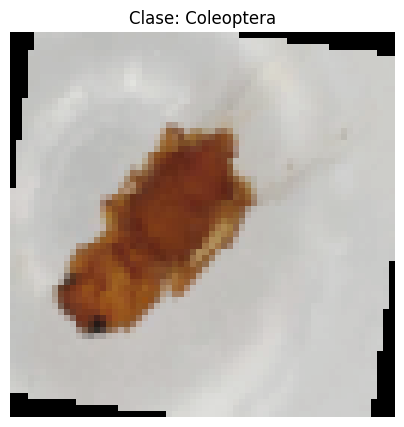

In [5]:
ix = random.randint(0, len(trainset) - 1)
img_t, label = trainset[ix]

mean = np.array(MEAN)
std = np.array(STD)
img = np.clip(std * img_t.permute(1, 2, 0).numpy() + mean, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Clase: {classes[label]}")
plt.axis("off")
plt.show()


Ahora, vamos a aplicar un filtro definido manualmente a esta imagen. En este caso aplicaremos un filtro de 3x3 con valores de 1 en la primera fila, 0 en la central y -1 en la última. Como puedes ver en el resultado, este filtro es útil para identificar líneas horizontales.

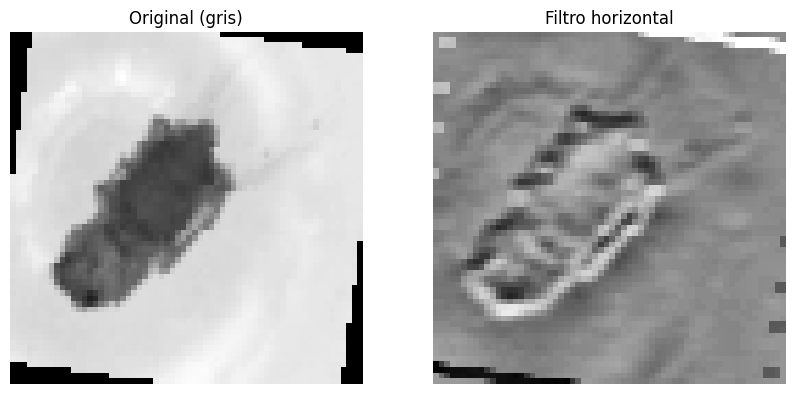

In [6]:
# Convertimos a escala de grises para aplicar filtros 2D manuales.
img_gray = color.rgb2gray(img)

# Filtro horizontal
kernel = np.array([[ 1,  1,  1],
                   [ 0,  0,  0],
                   [-1, -1, -1]])

edges = scipy.signal.convolve2d(img_gray, kernel, mode="valid")
edges = edges / (np.max(np.abs(edges)) + 1e-8)
edges = exposure.equalize_adapthist((edges + 1) / 2, clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_gray, cmap="gray")
ax1.set_title("Original (gris)")
ax1.axis("off")
ax2.imshow(edges, cmap="gray")
ax2.set_title("Filtro horizontal")
ax2.axis("off")
plt.show()


Si aplicamos ahora el mismo filtro, pero transpuesto, obtenemos un detector de líneas verticales.

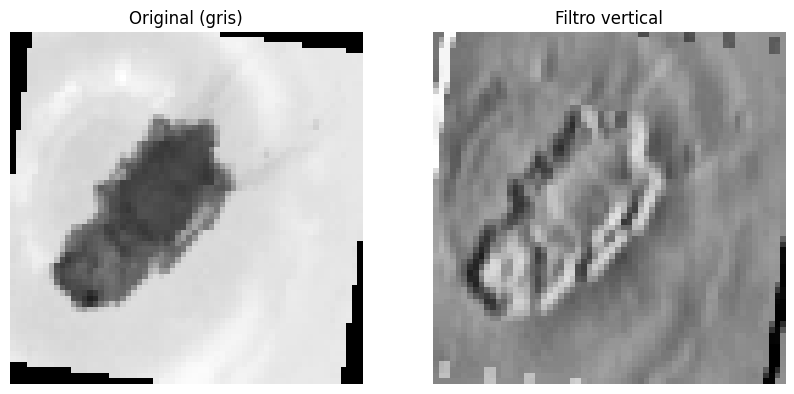

In [7]:
# Filtro vertical
kernel = np.array([[ 1, 0, -1],
                   [ 1, 0, -1],
                   [ 1, 0, -1]])

edges = scipy.signal.convolve2d(img_gray, kernel, mode="valid")
edges = edges / (np.max(np.abs(edges)) + 1e-8)
edges = exposure.equalize_adapthist((edges + 1) / 2, clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_gray, cmap="gray")
ax1.set_title("Original (gris)")
ax1.axis("off")
ax2.imshow(edges, cmap="gray")
ax2.set_title("Filtro vertical")
ax2.axis("off")
plt.show()


De la misma manera, el siguiente filtro será útil para detectar bordes en cualquier orientación.

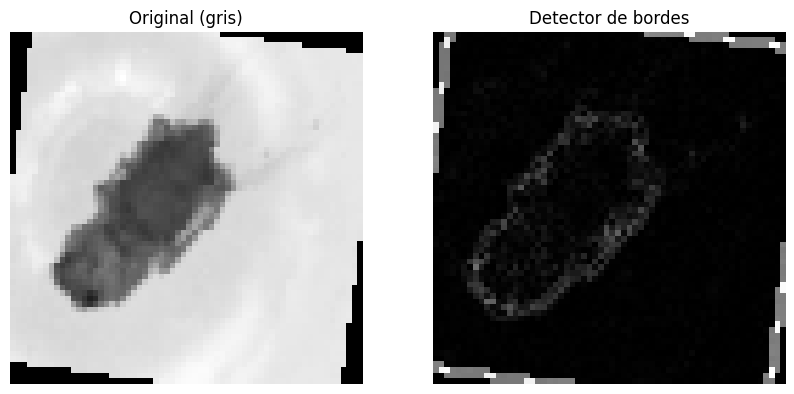

In [8]:
# Detector Laplaciano de bordes
kernel = np.array([[ 0, -1,  0],
                   [-1,  4, -1],
                   [ 0, -1,  0]])

edges = scipy.signal.convolve2d(img_gray, kernel, mode="valid")
edges = np.abs(edges)
edges = edges / (edges.max() + 1e-8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_gray, cmap="gray")
ax1.set_title("Original (gris)")
ax1.axis("off")
ax2.imshow(edges, cmap="gray")
ax2.set_title("Detector de bordes")
ax2.axis("off")
plt.show()


Como puedes ver, al aplicar varios filtros a nuestra imagen podemos obtener información relevante a la hora de llevar a cabo tareas tales como la clasificación de la imagen, detectar varios objetos en ella o generar una descripción textual de la misma. La pregunta ahora es: ¿Y cómo decidimos que filtros utilizar? La respuesta es fácil, dejaremos que sea la propia red neuronal quién aprenda estos valores a través del proceso de entrenamiento de manera que sea ella misma quien decida qué patrones son los más importantes a la hora de llevar a cabo su tarea. Así pues, los filtros serán ahora los parámetros de nuestra red.

### Implementación en Pytorch

En `Pytorch` tenemos implementada la capa convolucional en el clase `torch.nn.Conv2D`. A esta capa le pasamos como parámetros el número de canales de la imagen a la entrada, el número de filtros, el tamaño del filtro y otros parámetros relevantes de los que hablaremos más adelante. Si miras en la [documentación](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), esta capa espera un tensor a la entrada con dimensiones $(N,C_{in},H,W)$, dónde $N$ es el tamaño del *batch*, $C_{in}$ es el número de canales del mapa de entrada, $H$ es el alto y $W$ el ancho del mapa.

In [9]:
# El dataset ya devuelve tensores con formato (C, H, W).
# Agregamos una dimension de batch para obtener (N, C, H, W).
img_tensor = img_t.unsqueeze(0)
print("Tensor de entrada:", img_tensor.shape)


Tensor de entrada: torch.Size([1, 3, 64, 64])


In [10]:
# Aplicamos 10 filtros aprendibles de 3x3.
conv = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)
output = conv(img_tensor)
print("Salida Conv2d:", output.shape)


Salida Conv2d: torch.Size([1, 10, 62, 62])


Como puedes ver las dimensiones del tensor de salida son diferentes al tensor de entrada. En primer lugar, el número de canales del mapa de entrada ahora es el número de filtros aplicados (el resultado de aplicar cada filtro se guarda en un canal). En cuanto al ancho y alto, dependerá de la relación entre el tamaño de la imagen y el del filtro. Puedes calcular estas dimensiones de la siguiente manera

$$ o = \lfloor \frac{n+2p-m}{s} \rfloor + 1 $$

donde $o$ es la dimensión de salida, $n$ la de entrada, $m$ es el tamaño del filtro y $p$ y $s$ son dos parámetros con los que podemos jugar para ajustar el tamaño de salida. $p$ es el *padding* y consiste en el número de valores extra que añadimos en los bordes para aumentar el tamaño de la entrada. $s$ es el *stride*, y controla el número de pixeles que el filtro salta en cada paso. $\lfloor \cdot \rfloor$ es el operador *floor*, que redondea cualquier resultado a la baja.

Usar $p = 1$ y $s = 1$ con un filtro de 3x3 no cambiará el tamaño de la imagen.

In [11]:
# Stride=2 reduce aproximadamente a la mitad la resolucion espacial.
conv = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, padding=0, stride=2)
output = conv(img_tensor)
print("Salida con stride=2:", output.shape)


Salida con stride=2: torch.Size([1, 10, 31, 31])


Aplicar un salto de 2 pixeles en la aplicación del filtro, $s = 2$, reducirá el tamaño a la mitad.

In [12]:
# Padding=1 conserva mejor la informacion de los bordes.
conv = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, padding=1, stride=2)
output = conv(img_tensor)
print("Salida con padding=1 y stride=2:", output.shape)


Salida con padding=1 y stride=2: torch.Size([1, 10, 32, 32])


In [13]:
# Una segunda convolucion recibe los mapas de caracteristicas de la anterior.
conv2 = nn.Conv2d(in_channels=10, out_channels=64, kernel_size=3, padding=1, stride=1)
output2 = conv2(output)
print("Salida segunda convolucion:", output2.shape)


Salida segunda convolucion: torch.Size([1, 64, 32, 32])


En una `red convolucional` tendremos varias de estas `capas convolucionales` en diferentes capas consecutivas, de manera que las entradas a unas capas serán las salidas de las anteriores. De esta manera, la red será capaz de construir patrones cada vez más elaborados a partir de patrones más sencillos. Puedes ver una animación del funcionamiento de esta capa en el siguiente [vídeo](https://www.youtube.com/watch?v=f0t-OCG79-U). También, en el siguiente gif, puedes ver un ejemplo de aplicación.

![](https://thumbs.gfycat.com/AffectionateMemorableGreyhounddog-size_restricted.gif)


## Capas de *Pooling*

Si bien hemos visto que jugando con los tamaños del filtro, *stride* y *padding* podemos controlar el tamaño de los mapas generados por las capas convolucionales, es también común el uso de capas *pooling* para reducir los mapas de características.

![](https://miro.medium.com/max/1456/1*WvHC5bKyrHa7Wm3ca-pXtg.gif)

Estas capas también aplican un filtro sobre su entrada, pero en este caso es un solo filtro que además no tiene parámetros sino que aplica una función predeterminada en su campo receptivo (mínimo, máximo, promedio, etc). La idea detrás del uso de este tipo de capas es la de reducir la resolución de los mapas de características, reduciendo así el coste computacional para entrenar la `red neuronal`, pero manteniendo las características importantes para el reconocimiento de patrones.

In [14]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)
img_tensor = img_t.unsqueeze(0)
output = pool(img_tensor)
print("Antes del pool:", img_tensor.shape)
print("Despues del pool:", output.shape)


Antes del pool: torch.Size([1, 3, 64, 64])
Despues del pool: torch.Size([1, 3, 32, 32])


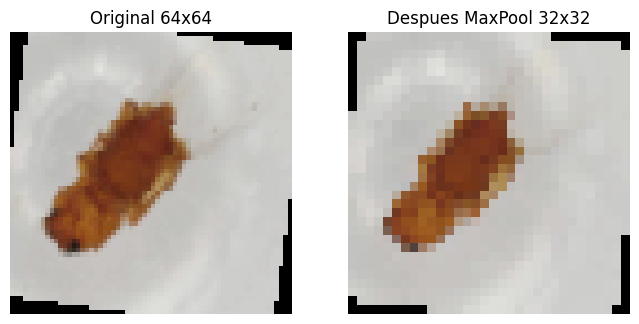

In [15]:
out_img = output.squeeze(0).permute(1, 2, 0).detach().numpy()
out_img = np.clip(std * out_img + mean, 0, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(img)
ax1.set_title("Original 64x64")
ax1.axis("off")
ax2.imshow(out_img)
ax2.set_title("Despues MaxPool 32x32")
ax2.axis("off")
plt.show()


## Redes Convolucionales

Una vez revisados los componentes principales de las redes convolucionales, implementamos una CNN completa para clasificar las imágenes del dataset de insectos. Se mantienen separadas las particiones de entrenamiento, validación y prueba para poder evaluar el modelo de forma correcta.

In [16]:
# DataLoaders. Val se usa durante el entrenamiento; test solo al final.
pin_memory = device.type == "cuda"

dataloader = {
    "train": DataLoader(
        trainset, batch_size=BATCH_SIZE, shuffle=True,
        pin_memory=pin_memory, num_workers=0
    ),
    "val": DataLoader(
        valset, batch_size=BATCH_SIZE, shuffle=False,
        pin_memory=pin_memory, num_workers=0
    ),
}

test_loader = DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False,
    pin_memory=pin_memory, num_workers=0
)

print("Batches train:", len(dataloader["train"]))
print("Batches val:  ", len(dataloader["val"]))
print("Batches test: ", len(test_loader))


Batches train: 278
Batches val:   60
Batches test:  60


Vamos a definir una `red convolucional` con varias `capas convolucionales` y `capas de pooling`. Para poder clasificar las imágenes, conectaremos las salidas de la última capa de la red convolucional con un `MLP` para obtener las predicciones finales.

In [17]:
def block(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(c_out),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )


class CNN(nn.Module):
    def __init__(self, n_channels=3, n_outputs=None):
        super().__init__()
        if n_outputs is None:
            n_outputs = len(classes)

        # 64 -> 32 -> 16 -> 8 -> 4
        self.features = nn.Sequential(
            block(n_channels, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
        )

        # Reduce cada mapa de caracteristicas a 1x1.
        # Esto evita una capa Fully Connected enorme y reduce overfitting.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.30)
        self.fc = nn.Linear(256, n_outputs)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


model = CNN(n_channels=3, n_outputs=len(classes))
with torch.no_grad():
    test_output = model(torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE))

print(model)
print("Salida de prueba:", test_output.shape)
print("Parametros entrenables:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, d

Utilizando capas convolucionales con filtros de 3x3, *padding* 1 y *stride* 1, mantenemos las dimensiones constantes dejando la responsabilidad de reducir la resolución a las capas *pooling*. Tras cada capa convolcuional, el número de canales corresponde con el número de filtros aplicados. Para conectar la última salida de la capa convolucional a la capa lineal, tenemos que estirar el último mapa de características en un vector de una sola dimensión.

Ahora, podemos entrenar la red utilizando nuestro bucle de entrenamiento.

In [18]:
# Pesos balanceados por clase.
# Se usan porque el dataset puede tener clases con cantidades distintas de imagenes.
counts = np.bincount(trainset.targets, minlength=len(classes)).astype(np.float32)
class_weights = len(trainset) / (len(classes) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)


def fit(model, dataloader, epochs=15, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)

    # AdamW agrega regularizacion mediante weight decay.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }

    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # -------- Entrenamiento --------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        bar = tqdm(dataloader["train"], desc=f"Epoch {epoch}/{epochs} [train]")
        for X, y in bar:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += batch_size

            bar.set_postfix(
                loss=f"{running_loss / total:.4f}",
                acc=f"{correct / total:.4f}",
            )

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- Validacion --------
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            bar = tqdm(dataloader["val"], desc=f"Epoch {epoch}/{epochs} [val]  ")
            for X, y in bar:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                loss = criterion(logits, y)

                batch_size = y.size(0)
                running_loss += loss.item() * batch_size
                correct += (logits.argmax(dim=1) == y).sum().item()
                total += batch_size

                bar.set_postfix(
                    val_loss=f"{running_loss / total:.4f}",
                    val_acc=f"{correct / total:.4f}",
                )

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Conservamos los pesos de la mejor epoca segun validation loss.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"loss={train_loss:.4f} acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"\nRestaurado mejor modelo (val_loss={best_val_loss:.4f}).")

    return history


In [19]:
model = CNN(n_channels=3, n_outputs=len(classes))
history = fit(model, dataloader, epochs=15, lr=1e-3, weight_decay=1e-4)


Epoch 1/15 [val]  : 100%|██████████| 60/60 [00:22<00:00,  2.69it/s, val_acc=0.4749, val_loss=1.6167]


Epoch 01/15 | loss=1.9821 acc=0.4178 | val_loss=1.6167 val_acc=0.4749


Epoch 2/15 [val]  : 100%|██████████| 60/60 [00:35<00:00,  1.69it/s, val_acc=0.6085, val_loss=1.2963]


Epoch 02/15 | loss=1.7423 acc=0.4880 | val_loss=1.2963 val_acc=0.6085


Epoch 3/15 [val]  : 100%|██████████| 60/60 [00:19<00:00,  3.03it/s, val_acc=0.4728, val_loss=1.5228]


...

Epoch 13/15 | loss=1.1761 acc=0.6200 | val_loss=1.2654 val_acc=0.5414


Epoch 14/15 [val]  : 100%|██████████| 60/60 [00:12<00:00,  4.70it/s, val_acc=0.6737, val_loss=0.9555]


Epoch 14/15 | loss=1.1196 acc=0.6302 | val_loss=0.9555 val_acc=0.6737


Epoch 15/15 [val]  : 100%|██████████| 60/60 [00:24<00:00,  2.40it/s, val_acc=0.5769, val_loss=1.2847]

Epoch 15/15 | loss=1.1040 acc=0.6416 | val_loss=1.2847 val_acc=0.5769

Restaurado mejor modelo (val_loss=0.9555).


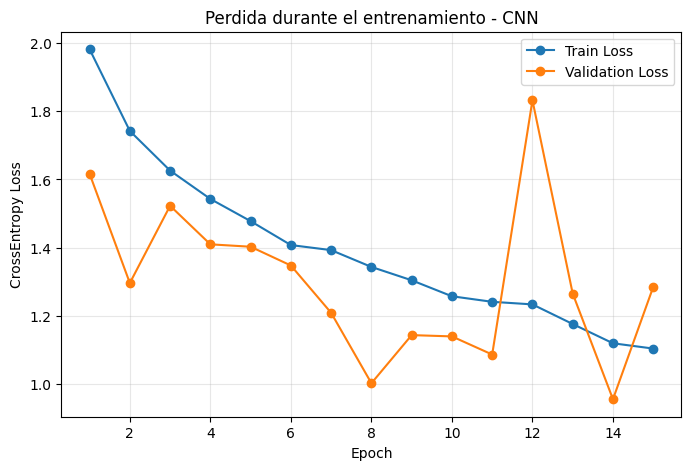

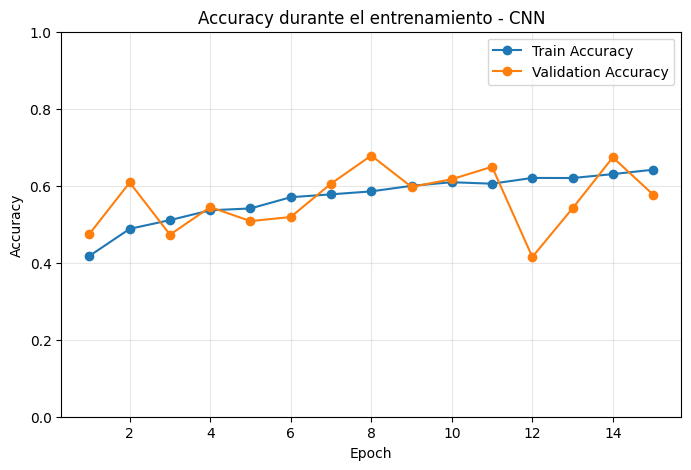

Mejor validation accuracy: 0.6784


In [20]:
epochs_range = range(1, len(history["train_loss"]) + 1)

# Grafica de perdida
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Perdida durante el entrenamiento - CNN")
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Grafica de accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")
plt.title("Accuracy durante el entrenamiento - CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Mejor validation accuracy:", round(max(history["val_acc"]), 4))


## Evaluación final en el conjunto de test

El conjunto de **test** no se utiliza para ajustar el modelo. Se usa una sola vez al final para medir su capacidad de generalización. Además de *accuracy*, se calcula **Macro F1**, una métrica útil cuando existe desbalance entre clases.

In [21]:
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    total_loss = 0.0
    total = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for X, y in tqdm(loader, desc="Evaluando TEST"):
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            batch_size = y.size(0)
            total_loss += loss.item() * batch_size
            total += batch_size

            predictions = logits.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    test_loss = total_loss / total
    test_acc = accuracy_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred, average="macro")

    return test_loss, test_acc, test_f1, np.array(y_true), np.array(y_pred)


test_loss, test_acc, test_f1, y_true, y_pred = evaluate(model, test_loader)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"Macro F1:      {test_f1:.4f}")


Evaluando TEST: 100%|██████████| 60/60 [00:29<00:00,  2.04it/s]

Test Loss:     0.9815
Test Accuracy: 0.6730 (67.30%)
Macro F1:      0.4873


## Matriz de confusión

La matriz está normalizada por clase real. Cada fila representa una clase verdadera y muestra qué proporción de sus imágenes fue asignada a cada clase predicha.

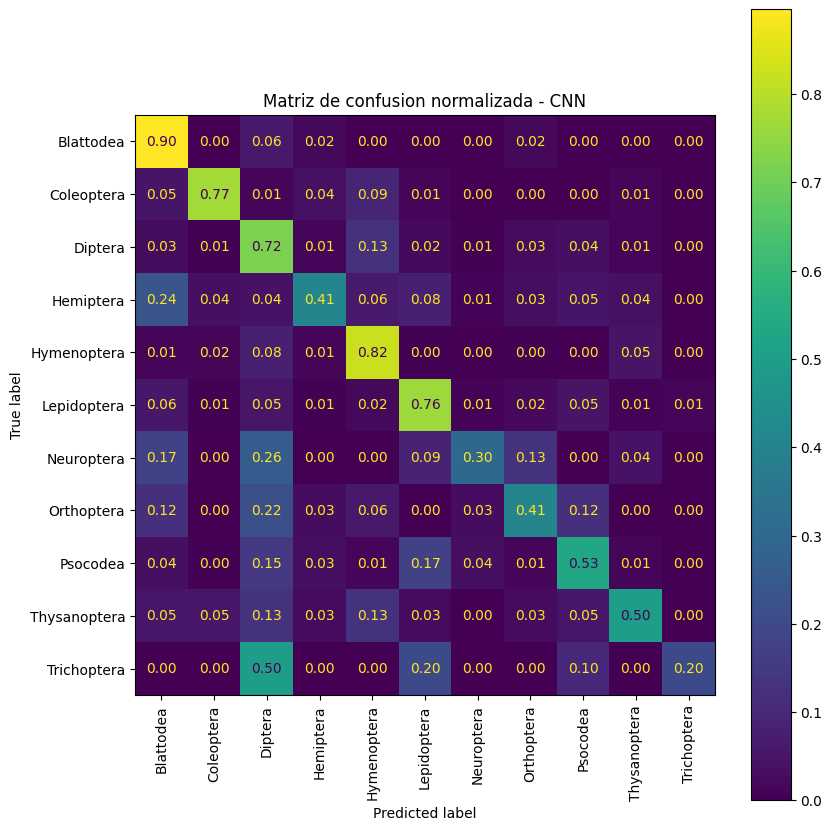

In [22]:
cm = confusion_matrix(y_true, y_pred, normalize="true")

fig_size = max(8, min(18, len(classes) * 0.8))
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=90, values_format=".2f", colorbar=True)
plt.title("Matriz de confusion normalizada - CNN")
plt.tight_layout()
plt.show()


## Métricas por clase

In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
))


              precision    recall  f1-score   support

   Blattodea     0.1303    0.8958    0.2275        48
  Coleoptera     0.9221    0.7733    0.8412       750
     Diptera     0.7394    0.7187    0.7289       750
   Hemiptera     0.8266    0.4067    0.5451       750
 Hymenoptera     0.7288    0.8240    0.7735       750
 Lepidoptera     0.6643    0.7641    0.7107       373
  Neuroptera     0.2258    0.3043    0.2593        23
  Orthoptera     0.1667    0.4062    0.2364        32
    Psocodea     0.6157    0.5321    0.5709       280
Thysanoptera     0.1727    0.5000    0.2568        38
 Trichoptera     0.2222    0.2000    0.2105        10

    accuracy                         0.6730      3804
   macro avg     0.4922    0.5750    0.4873      3804
weighted avg     0.7514    0.6730    0.6908      3804



## Resultados de la CNN

Los valores de **Test Accuracy**, **Macro F1** y **Test Loss** obtenidos aquí pueden utilizarse después para comparar esta CNN con el modelo basado en **Multi-Head Attention**, manteniendo las mismas particiones del dataset, resolución de 64×64 y métricas de evaluación.